# 04 — Detection vs Attribution (proposal 3.3.4) → RQ1

In [1]:
%load_ext autoreload
%autoreload 2

import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))  # so `import src...` works from notebooks/

import numpy as np
import pandas as pd

from src import config
from src.utils import set_seed, save_fig
set_seed()  # fix all RNGs -- reproducibility

Collapse all 11 LLMs into one `ai` class, rerun the SAME pipeline binary, compare against 12-way to quantify the attribution difficulty gap.

In [2]:
from src import data, features, modeling
clean = data.load_or_build_clean(); splits = data.load_or_build_splits(clean)
y12 = clean[config.LABEL_COL].values
y_bin = np.where(y12 == config.HUMAN_CLASS, 'human', 'ai')

In [3]:
# Best feature set = exp6_all (full model) + logreg (proposal's primary
# classifier) -- same condition, only the label vector changes.
import time

texts = clean['text']
X_tfidf, _ = features.build_tfidf(texts.iloc[splits['train']], texts)
sty = features.build_stylometric(texts)
sty_scaled, _ = features.scale_dense(sty.values, splits['train'])
bib = features.build_biber(texts)
bib_scaled, _ = features.scale_dense(bib.values, splits['train'])
emb = features.build_sbert(texts)   # cached
print(f'[{time.time():.0f}] features built')

blocks = {
    'tfidf': X_tfidf, 'stylometric': sty_scaled, 'biber': bib_scaled,
    'sbert': emb, 'length': clean[['log_token_count']].values,
}
X = features.assemble(blocks, features.EXPERIMENTS['exp6_all'], splits['train'])
Xtr, Xval = X[splits['train']], X[splits['val']]
ytr12, yval12 = y12[splits['train']], y12[splits['val']]
ytr_bin, yval_bin = y_bin[splits['train']], y_bin[splits['val']]

t0 = time.time()
res_12way = modeling.train_and_evaluate('logreg', Xtr, ytr12, Xval, yval12)
print(f'12-way fit done in {time.time()-t0:.1f}s (macro_f1={res_12way.macro_f1:.3f})')

t0 = time.time()
res_binary = modeling.train_and_evaluate('logreg', Xtr, ytr_bin, Xval, yval_bin)
print(f'binary fit done in {time.time()-t0:.1f}s (macro_f1={res_binary.macro_f1:.3f})')

gap = res_binary.macro_f1 - res_12way.macro_f1
print(f"Binary Macro-F1: {res_binary.macro_f1:.4f}")
print(f"12-way Macro-F1: {res_12way.macro_f1:.4f}")
print(f"Attribution gap: {gap:.4f}")

[1783920001] features built


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


12-way fit done in 2222.8s (macro_f1=0.777)
binary fit done in 342.7s (macro_f1=0.904)
Binary Macro-F1: 0.9042
12-way Macro-F1: 0.7769
Attribution gap: 0.1274


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


PosixPath('/Users/xinye/Desktop/module 3/5 nautral language proccesing/syndicate asm/llm-source-attribution/figures/detection_vs_attribution.png')

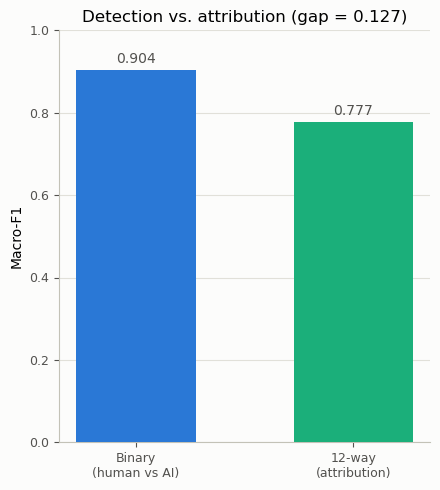

In [4]:
from src import viz

pd.DataFrame({
    'binary': {'macro_f1': res_binary.macro_f1, 'accuracy': res_binary.accuracy},
    '12way': {'macro_f1': res_12way.macro_f1, 'accuracy': res_12way.accuracy},
}).T.to_csv(config.ARTIFACTS / 'detection_vs_attribution.csv')

fig, ax = viz.new_fig(figsize=(4.5, 5))
labels = ['Binary\n(human vs AI)', '12-way\n(attribution)']
vals = [res_binary.macro_f1, res_12way.macro_f1]
bars = ax.bar(labels, vals, color=viz.CATEGORICAL[:2], width=0.55, zorder=3)
ax.bar_label(bars, fmt='%.3f', color=viz.INK_SECONDARY, padding=3)
ax.set_ylabel('Macro-F1')
ax.set_ylim(0, 1)
ax.set_title(f'Detection vs. attribution (gap = {gap:.3f})')
fig.tight_layout()
save_fig(fig, 'detection_vs_attribution')

### Conclusion (RQ1)

**Binary detection (0.904) is substantially easier than 12-way attribution
(0.777) — a gap of 0.127 Macro-F1**, using the identical feature set
(Exp6, all features) and classifier (logreg), so the gap isolates the cost
of moving from "is this AI-generated" to "which of 11 models wrote this."

This is a clean, direct answer to RQ1's detection-vs-attribution framing:
telling human from AI is close to solved with these features (0.90), but
telling the 11 LLMs apart from each other is meaningfully harder — most of
that remaining difficulty is inter-model confusion, not human/AI confusion,
which is exactly what `05_error_analysis`'s confusion matrix goes on to
characterize (the off-diagonal mass concentrates among specific LLM pairs
like mistral↔mpt and cohere↔cohere-chat, not around the human row/column).

Cross-check: this 12-way Macro-F1 (0.7769) matches `03_ablation`'s
Exp6/logreg result (0.777) almost exactly, as it should — both notebooks
assemble the identical feature set independently, which is a useful sanity
check that the pipeline is self-consistent across notebooks.